# Notebook 20 — Branch A: Intention Classification (Stage 2)

Fine-tune the pretrained depth backbone on the custom dataset for **intention classification** (3 classes: Idle, Reaching, Grabbing).

**Architecture:**
```
Pretrained Backbone (frozen):
  Input: (B, 1, 16, 64, 64)
  → 3D CNN + Transformer → (B, 128)

Branch A Head (trainable):
  (B, 128) → Linear(128→64) → ReLU → Linear(64→3) → (B, 3) logits
```

**Training Strategy:**
- Freeze backbone, train only Branch A head
- Use CrossEntropyLoss with class weights (if imbalanced)
- Early stopping on validation F1-score

## Table of Contents
1. [Environment & Imports](#1)
2. [Load Data](#2)
3. [Load Pretrained Backbone](#3)
4. [Build Model with Branch A](#4)
5. [Training Loop](#5)
6. [Evaluation & Visualization](#6)
7. [Save Model](#7)


---
## 1. Environment & Imports <a id='1'></a>

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Set paths
SRC = Path('..') / 'src'
if str(SRC.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC.resolve()))

from config import PROC_DIR

CUSTOM_PROC_DIR = PROC_DIR / 'custom'
MODELS_DIR = PROC_DIR.parent / 'models'
MODELS_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

# Random seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Label names
LABEL_NAMES = ['Idle', 'Reaching', 'Grabbing']
NUM_CLASSES = 3

Device: cuda
PyTorch: 2.11.0+cu130


---
## 2. Load Data <a id='2'></a>

In [2]:
class CustomDepthDataset(Dataset):
    """Load custom prepared depth dataset for classification or regression."""
    def __init__(self, npz_path):
        data = np.load(npz_path)
        self.X = torch.from_numpy(data['X']).unsqueeze(1)  # (M, T, H, W) → (M, 1, T, H, W)
        # y can be either labels (int) or poses (22, 3)
        y_data = data['y']
        if y_data.ndim == 1:
            # Classification labels
            self.y = torch.from_numpy(y_data).long()
        else:
            # Regression targets (poses)
            self.y = torch.from_numpy(y_data).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].float(), self.y[idx]

# Load datasets
print('Loading custom dataset...')
train_ds = CustomDepthDataset(CUSTOM_PROC_DIR / 'branch_a_train.npz')
val_ds = CustomDepthDataset(CUSTOM_PROC_DIR / 'branch_a_val.npz')
test_ds = CustomDepthDataset(CUSTOM_PROC_DIR / 'branch_a_test.npz')

print(f'Train: {len(train_ds)} windows')
print(f'Val:   {len(val_ds)} windows')
print(f'Test:  {len(test_ds)} windows')

# Check sample
x_sample, y_sample = train_ds[0]
print(f'\nSample shapes:')
print(f'  X: {x_sample.shape}')
print(f'  y: {y_sample}')

Loading custom dataset...
Train: 172 windows
Val:   36 windows
Test:  52 windows

Sample shapes:
  X: torch.Size([1, 16, 64, 64])
  y: 0


In [3]:
# Compute class weights for imbalanced dataset
train_labels = train_ds.y.numpy()
unique_labels, counts = np.unique(train_labels, return_counts=True)

print('\nClass distribution:')
class_weights = []
total = len(train_labels)
for lbl, cnt in zip(unique_labels, counts):
    weight = total / (len(unique_labels) * cnt)  # Inverse frequency weighting
    class_weights.append(weight)
    print(f'  {LABEL_NAMES[lbl]}: {cnt:3d} ({100*cnt/total:5.1f}%) → weight={weight:.3f}')

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'\nClass weights: {class_weights}')


Class distribution:
  Idle:  19 ( 11.0%) → weight=3.018
  Reaching: 101 ( 58.7%) → weight=0.568
  Grabbing:  52 ( 30.2%) → weight=1.103

Class weights: tensor([3.0175, 0.5677, 1.1026], device='cuda:0')


---
## 3. Load Pretrained Backbone <a id='3'></a>

In [4]:
# Load backbone checkpoint from Stage 1
backbone_path = PROC_DIR / 'stage1_best.pth'

if not backbone_path.exists():
    # Try alternative path from notebook 02
    print(f'⚠ Not found: {backbone_path}')
    print('Checking alternative paths...')
    alt_paths = [
        PROC_DIR / 'pretrained_depth_backbone.pth',
        MODELS_DIR / 'stage1_pretrained_backbone.pth',
    ]
    for alt_path in alt_paths:
        if alt_path.exists():
            backbone_path = alt_path
            print(f'✓ Using: {backbone_path}')
            break
    else:
        print('✗ No backbone found! Run notebook 02 first.')

print(f'\nLoading backbone from: {backbone_path}')
ckpt = torch.load(backbone_path, weights_only=False)
print(f'Checkpoint keys: {ckpt.keys()}')


Loading backbone from: D:\course\comp4471\comp4471-project\dataset\processed\stage1_best.pth
Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'val_error_mean', 'val_error_palm', 'scale_factor'])


---
## 4. Build Model with Branch A <a id='4'></a>

In [7]:
class DepthToSkeletonBackbone(nn.Module):
    """Backbone extracted from Stage 1 model (CNN + Transformer)."""
    def __init__(self, d_model=128):
        super().__init__()
        # CNN: (B, 1, T, 64, 64) → (B, 128, T/2, 8, 8)
        self.cnn = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=(3,5,5), padding=(1,2,2)),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((1,2,2)),
            
            nn.Conv3d(32, 64, kernel_size=(3,3,3), padding=(1,1,1)),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((1,2,2)),
            
            nn.Conv3d(64, 128, kernel_size=(3,3,3), padding=(1,1,1)),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((2,2,2)),
        )
        
        self.spatial_proj = nn.Linear(128, d_model)
        self.temporal_tokens = 8
        self.pos_enc = nn.Parameter(torch.randn(1, self.temporal_tokens, d_model) * 0.02)
        
        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=4, dim_feedforward=d_model*4,
            dropout=0.1, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
    
    def forward(self, depth):
        """Input: (B, 1, T, 64, 64) → Output: (B, 128)"""
        B, _, T, _, _ = depth.shape
        
        # CNN encoding
        x = self.cnn(depth)  # (B, 128, T/2, 8, 8)
        B, C, T_new, _, _ = x.shape
        
        # Spatial pooling per frame
        x = x.permute(0, 2, 1, 3, 4)  # (B, T_new, 128, 8, 8)
        x = x.reshape(B, T_new, C, -1).mean(dim=3)  # (B, T_new, 128)
        
        # Project and add positional encoding
        x = self.spatial_proj(x)  # (B, T_new, d_model)
        x = x + self.pos_enc[:, :T_new, :]
        
        # Temporal reasoning
        x = self.transformer(x)
        feat = x.mean(dim=1)  # (B, d_model)
        
        return feat

# Build complete model
class BranchAIntentionModel(nn.Module):
    """Full model: frozen backbone + trainable Branch A head."""
    def __init__(self, num_classes=3, d_model=128):
        super().__init__()
        self.backbone = DepthToSkeletonBackbone(d_model=d_model)
        
        # Branch A: Intention classifier (128→64→3)
        self.branch_a = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
        )
    
    def forward(self, depth, return_features=False):
        """Input: (B, 1, T, 64, 64) → Output: (B, num_classes)"""
        feat = self.backbone(depth)
        logits = self.branch_a(feat)
        
        if return_features:
            return logits, feat
        return logits

# Initialize model
model = BranchAIntentionModel(num_classes=NUM_CLASSES).to(device)

# Load backbone weights
backbone_target = model.backbone.state_dict()
if 'backbone' in ckpt:
    # Stage 1 checkpoint with separate backbone dict
    backbone_state = ckpt['backbone']
    if isinstance(backbone_state, dict):
        if any(k.startswith('backbone.') for k in backbone_state.keys()):
            backbone_state = {
                k.replace('backbone.', '', 1): v
                for k, v in backbone_state.items()
                if k.startswith('backbone.')
            }
        filtered_backbone_state = {k: v for k, v in backbone_state.items() if k in backbone_target}
        model.backbone.load_state_dict(filtered_backbone_state, strict=False)
    print('✓ Loaded backbone from Stage 1 checkpoint')
elif 'model_state_dict' in ckpt:
    # Stage 1 checkpoint stores the backbone directly in model_state_dict
    state_dict = ckpt['model_state_dict']
    if any(k.startswith('backbone.') for k in state_dict.keys()):
        backbone_dict = {
            k.replace('backbone.', '', 1): v
            for k, v in state_dict.items()
            if k.startswith('backbone.')
        }
    else:
        backbone_dict = state_dict
    # Keep only parameters that exist in the current backbone and ignore decoder/head keys
    filtered_backbone_dict = {k: v for k, v in backbone_dict.items() if k in backbone_target}
    model.backbone.load_state_dict(filtered_backbone_dict, strict=False)
    print('✓ Loaded backbone from full model checkpoint')

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False
print('✓ Frozen backbone')

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel parameters:')
print(f'  Total:     {total_params:,}')
print(f'  Trainable: {trainable_params:,} (Branch A head only)')

✓ Loaded backbone from full model checkpoint
✓ Frozen backbone

Model parameters:
  Total:     900,355
  Trainable: 8,451 (Branch A head only)


---
## 5. Training Loop <a id='5'></a>

In [9]:
# Hyperparameters
BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=0, pin_memory=True if device.type == 'cuda' else False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True if device.type == 'cuda' else False)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
)

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
}

best_val_f1 = 0.0
patience_counter = 0
MAX_PATIENCE = 15

print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {NUM_EPOCHS}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Early stopping patience: {MAX_PATIENCE}\n')

Batch size: 8
Epochs: 50
Learning rate: 0.0005
Early stopping patience: 15



In [10]:
# Training loop
for epoch in range(NUM_EPOCHS):
    # ─── TRAIN ───
    model.train()
    train_loss_accum = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]', dynamic_ncols=True)
    for batch_idx, (depth, labels) in enumerate(pbar):
        depth = depth.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        logits = model(depth)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss_accum += loss.item()
        
        if batch_idx % 5 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss = train_loss_accum / len(train_loader)
    history['train_loss'].append(train_loss)
    
    # ─── VALIDATION ───
    model.eval()
    val_loss_accum = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]', dynamic_ncols=True)
        for depth, labels in pbar_val:
            depth = depth.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            logits = model(depth)
            loss = criterion(logits, labels)
            val_loss_accum += loss.item()
            
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    val_loss = val_loss_accum / len(val_loader)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    val_acc = (all_preds == all_labels).mean()
    val_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}:')
    print(f'  Train loss: {train_loss:.4f}')
    print(f'  Val loss:   {val_loss:.4f}')
    print(f'  Val acc:    {val_acc:.4f}  Val F1: {val_f1:.4f}')
    print(f'  LR:         {optimizer.param_groups[0]["lr"]:.2e}')
    
    # Early stopping based on F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1,
        }, MODELS_DIR / 'branch_a_best.pth')
        print(f'  ✓ Best model saved (F1={val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{MAX_PATIENCE})')
        
        if patience_counter >= MAX_PATIENCE:
            print(f'  → Early stopping at epoch {epoch+1}')
            break
    
    scheduler.step(val_f1)

print('\n' + '='*60)
print('Training complete!')
print('='*60)

Epoch 1/50 [Train]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]


Epoch 1/50:
  Train loss: 1.0541
  Val loss:   1.3404
  Val acc:    0.0000  Val F1: 0.0000
  LR:         5.00e-04
  No improvement (1/15)


Epoch 2/50 [Train]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 2/50 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 27/50 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]


Epoch 27/50:
  Train loss: 0.3734
  Val loss:   2.3370
  Val acc:    0.5278  Val F1: 0.5278
  LR:         1.25e-04
  No improvement (14/15)


Epoch 28/50 [Train]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 28/50 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]


Epoch 28/50:
  Train loss: 0.3870
  Val loss:   2.3084
  Val acc:    0.5278  Val F1: 0.5278
  LR:         1.25e-04
  No improvement (15/15)
  → Early stopping at epoch 28

Training complete!


---
## 6. Evaluation & Visualization <a id='6'></a>

Loaded best model from epoch 12
  Val F1: 0.5278  Val Acc: 0.5278


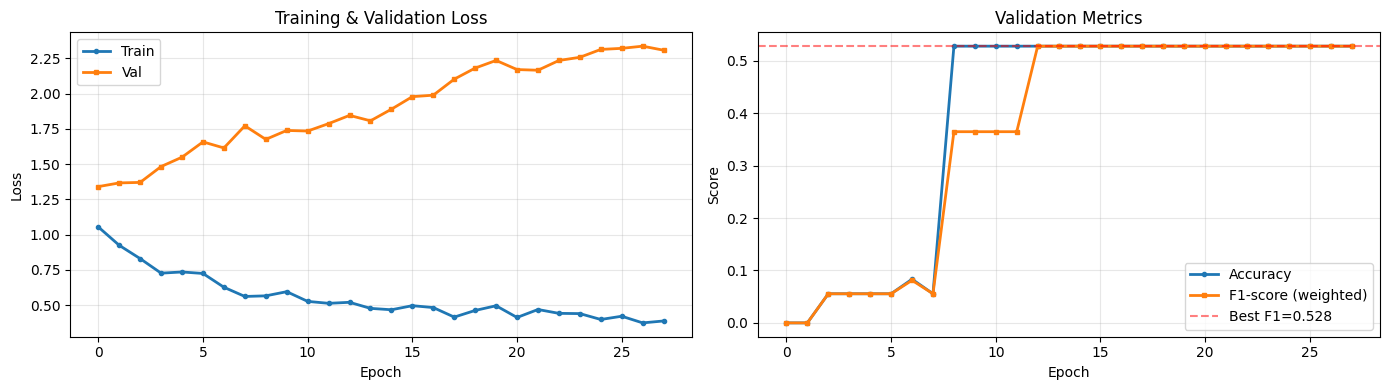

✓ Saved training curves


In [13]:
# Load best model
best_path = MODELS_DIR / 'branch_a_best.pth'
if not best_path.exists():
    raise FileNotFoundError(f'Best checkpoint not found: {best_path}')

try:
    best_ckpt = torch.load(best_path, map_location=device, weights_only=False)
except TypeError:
    # Older PyTorch versions do not accept weights_only
    best_ckpt = torch.load(best_path, map_location=device)

model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()

best_epoch = best_ckpt.get('epoch', 'unknown')
best_val_f1_ckpt = best_ckpt.get('val_f1', float('nan'))
best_val_acc_ckpt = best_ckpt.get('val_acc', float('nan'))
print(f'Loaded best model from epoch {best_epoch}')
print(f'  Val F1: {best_val_f1_ckpt:.4f}  Val Acc: {best_val_acc_ckpt:.4f}')

# Plot training curves
if len(history['train_loss']) == 0 or len(history['val_loss']) == 0:
    print('⚠ Training history is empty; skipping curve plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss curve
    axes[0].plot(history['train_loss'], label='Train', linewidth=2, marker='o', markersize=3)
    axes[0].plot(history['val_loss'], label='Val', linewidth=2, marker='s', markersize=3)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Metrics curve
    axes[1].plot(history['val_acc'], label='Accuracy', linewidth=2, marker='o', markersize=3)
    axes[1].plot(history['val_f1'], label='F1-score (weighted)', linewidth=2, marker='s', markersize=3)
    axes[1].axhline(best_val_f1, color='red', linestyle='--', alpha=0.5, label=f'Best F1={best_val_f1:.3f}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].set_title('Validation Metrics')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'branch_a_training_curves.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✓ Saved training curves')

In [14]:
# Evaluate on test set
model.eval()
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds = []
all_labels = []
with torch.no_grad():
    for depth, labels in tqdm(test_loader, desc='Testing'):
        depth = depth.to(device)
        logits = model(depth)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

test_acc = (all_preds == all_labels).mean()
test_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print('\nTest Set Results:')
print(f'  Accuracy: {test_acc:.4f}')
print(f'  F1-score: {test_f1:.4f}')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES, zero_division=0))

Testing:   0%|          | 0/7 [00:00<?, ?it/s]


Test Set Results:
  Accuracy: 0.5577
  F1-score: 0.6829

Classification Report:
              precision    recall  f1-score   support

        Idle       0.00      0.00      0.00         0
    Reaching       1.00      0.39      0.57        38
    Grabbing       1.00      1.00      1.00        14

    accuracy                           0.56        52
   macro avg       0.67      0.46      0.52        52
weighted avg       1.00      0.56      0.68        52



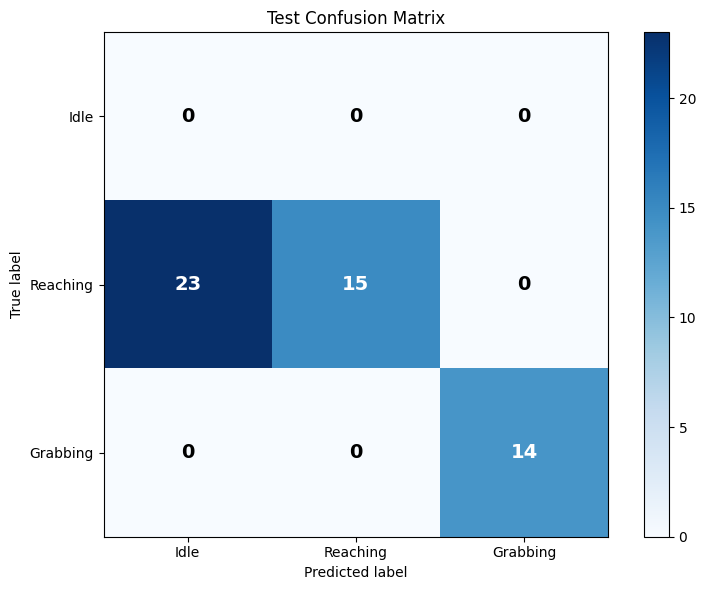

✓ Saved confusion matrix


In [15]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

# Labels
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(LABEL_NAMES)
ax.set_yticklabels(LABEL_NAMES)
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
ax.set_title('Test Confusion Matrix')

# Annotations
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        text = ax.text(j, i, cm[i, j], ha='center', va='center',
                       color='white' if cm[i, j] > cm.max()/2 else 'black',
                       fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'branch_a_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved confusion matrix')

---
## 7. Save Model <a id='7'></a>

In [ ]:
# Save final model checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'training_info': {
        'stage': 2,
        'task': 'intention_classification',
        'num_classes': NUM_CLASSES,
        'best_epoch': best_ckpt['epoch'],
        'val_acc': float(best_ckpt['val_acc']),
        'val_f1': float(best_ckpt['val_f1']),
        'test_acc': float(test_acc),
        'test_f1': float(test_f1),
    }
}, MODELS_DIR / 'branch_a_final.pth')

print('✓ Saved final model')
print(f'  Path: {MODELS_DIR / "branch_a_final.pth"}')
print(f'\nBranch A (Intention Classifier)')
print(f'  Input:  (B, 1, 16, 64, 64) depth sequences')
print(f'  Output: (B, 3) logits → {LABEL_NAMES}')
print(f'  Best validation F1: {float(best_ckpt["val_f1"]):.4f}')
print(f'  Test accuracy: {test_acc:.4f}')